# Import libararies

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [3]:
training_data = pd.read_csv('har_train.csv')

In [5]:
training_data

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
0,A,1.41,8.07,-94.4,3,0.00,0.00,-0.02,-21,4,...,36,0.03,0.00,-0.02,192,203,-215,-17,654,476
1,A,1.41,8.07,-94.4,3,0.02,0.00,-0.02,-22,4,...,36,0.02,0.00,-0.02,192,203,-216,-18,661,473
2,A,1.42,8.07,-94.4,3,0.00,0.00,-0.02,-20,5,...,36,0.03,-0.02,0.00,196,204,-213,-18,658,469
3,A,1.48,8.05,-94.4,3,0.02,0.00,-0.03,-22,3,...,36,0.02,-0.02,0.00,189,206,-214,-16,658,469
4,A,1.45,8.06,-94.4,3,0.02,0.00,-0.02,-21,4,...,36,0.02,-0.02,-0.03,193,203,-215,-9,660,478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13732,E,154.00,-32.70,125.0,24,0.29,0.05,-0.36,67,51,...,32,1.36,-2.83,-0.61,-227,221,0,-592,-85,431
13733,E,154.00,-32.90,126.0,24,0.31,0.05,-0.41,69,52,...,31,1.33,-2.89,-0.71,-230,200,-8,-571,-126,404
13734,E,145.00,-35.50,130.0,19,0.37,0.00,-0.64,47,13,...,29,1.54,-1.20,0.05,-263,-99,-45,-116,-654,-70
13735,E,143.00,-35.90,131.0,18,0.37,-0.02,-0.59,46,18,...,32,1.48,-0.90,0.05,-270,-141,-51,-68,-678,-98


In [6]:
testing_data = pd.read_csv('har_validate.csv')

In [7]:
testing_data

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
0,A,1.48,8.07,-94.4,3,0.02,0.02,-0.02,-21,2,...,36,0.02,0.00,-0.02,189,206,-214,-17,655.0,473.0
1,A,1.45,8.17,-94.4,3,0.03,0.00,0.00,-21,4,...,36,0.02,0.00,-0.02,190,205,-215,-22,656.0,473.0
2,A,1.42,8.21,-94.4,3,0.02,0.00,-0.02,-22,4,...,36,0.00,-0.02,-0.03,193,202,-214,-14,659.0,478.0
3,A,1.48,8.15,-94.4,3,0.00,0.00,0.00,-21,4,...,36,0.02,0.00,0.00,194,204,-215,-13,656.0,471.0
4,A,1.51,8.12,-94.4,3,0.00,0.00,-0.02,-21,4,...,36,0.02,-0.02,0.00,192,204,-213,-13,653.0,481.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5880,E,156.00,-32.10,124.0,25,0.22,0.05,-0.28,74,52,...,36,1.38,-2.94,-0.48,-193,291,3,-683,152.0,555.0
5881,E,151.00,-33.80,127.0,23,0.35,0.02,-0.54,60,47,...,25,1.51,-2.18,-1.02,-241,33,-17,-377,-420.0,173.0
5882,E,148.00,-34.70,129.0,21,0.37,0.00,-0.62,49,25,...,27,1.75,-1.91,-0.38,-255,-50,-30,-226,-570.0,27.0
5883,E,147.00,-34.80,129.0,21,0.37,-0.02,-0.67,50,26,...,29,1.73,-1.75,-0.25,-271,-68,-37,-205,-587.0,6.0


In [9]:
training_data.shape

(13737, 53)

In [10]:
testing_data.shape

(5885, 53)

In [11]:
training_data.describe()

,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,accel_belt_z,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
count,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,...,13737.000000,13737.000000,13737.00000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000,13737.000000
mean,64.503131,0.191794,-10.941653,11.317973,-0.004831,0.040013,-0.130328,-5.424620,30.152362,-72.748271,...,34.717551,0.159878,0.06067,0.142131,-61.736915,163.438087,-55.328383,-311.819611,379.741210,391.859212
std,62.768030,22.363296,95.374331,7.744534,0.206729,0.078435,0.241559,29.697752,28.560242,100.410466,...,10.089365,0.629520,2.15904,0.601628,180.263200,200.714691,138.501162,346.766862,511.403542,370.396450
min,-28.900000,-54.900000,-180.000000,0.000000,-1.040000,-0.640000,-1.350000,-120.000000,-69.000000,-269.000000,...,0.000000,-3.360000,-7.02000,-8.090000,-498.000000,-585.000000,-410.000000,-1280.000000,-892.000000,-973.000000
25%,1.100000,1.670000,-88.300000,3.000000,-0.030000,0.000000,-0.200000,-21.000000,3.000000,-162.000000,...,29.000000,-0.220000,-1.46000,-0.180000,-178.000000,54.000000,-182.000000,-613.000000,-3.000000,187.000000
50%,114.000000,5.260000,-12.700000,17.000000,0.030000,0.020000,-0.100000,-15.000000,35.000000,-152.000000,...,36.000000,0.050000,0.03000,0.080000,-57.000000,200.000000,-39.000000,-378.000000,595.000000,509.000000
75%,123.000000,14.800000,13.600000,18.000000,0.110000,0.110000,-0.020000,-5.000000,61.000000,27.000000,...,41.000000,0.560000,1.64000,0.490000,76.000000,312.000000,26.000000,-72.000000,737.000000,652.000000
max,162.000000,60.300000,179.000000,28.000000,2.220000,0.640000,1.620000,83.000000,164.000000,105.000000,...,73.000000,3.520000,6.13000,4.310000,477.000000,589.000000,291.000000,666.000000,1480.000000,1090.000000


In [12]:
training_data.tail(5)

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
13732,E,154.0,-32.7,125.0,24,0.29,0.05,-0.36,67,51,...,32,1.36,-2.83,-0.61,-227,221,0,-592,-85,431
13733,E,154.0,-32.9,126.0,24,0.31,0.05,-0.41,69,52,...,31,1.33,-2.89,-0.71,-230,200,-8,-571,-126,404
13734,E,145.0,-35.5,130.0,19,0.37,0.00,-0.64,47,13,...,29,1.54,-1.20,0.05,-263,-99,-45,-116,-654,-70
13735,E,143.0,-35.9,131.0,18,0.37,-0.02,-0.59,46,18,...,32,1.48,-0.90,0.05,-270,-141,-51,-68,-678,-98
13736,E,143.0,-36.0,132.0,18,0.35,-0.02,-0.57,42,25,...,33,1.38,-0.64,0.08,-278,-159,-52,-60,-686,-110


In [13]:
testing_data.tail(5)

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
5880,E,156.0,-32.1,124.0,25,0.22,0.05,-0.28,74,52,...,36,1.38,-2.94,-0.48,-193,291,3,-683,152.0,555.0
5881,E,151.0,-33.8,127.0,23,0.35,0.02,-0.54,60,47,...,25,1.51,-2.18,-1.02,-241,33,-17,-377,-420.0,173.0
5882,E,148.0,-34.7,129.0,21,0.37,0.00,-0.62,49,25,...,27,1.75,-1.91,-0.38,-255,-50,-30,-226,-570.0,27.0
5883,E,147.0,-34.8,129.0,21,0.37,-0.02,-0.67,50,26,...,29,1.73,-1.75,-0.25,-271,-68,-37,-205,-587.0,6.0
5884,E,145.0,-35.3,130.0,19,0.39,-0.02,-0.67,47,15,...,29,1.59,-1.36,0.00,-271,-91,-43,-151,-635.0,-36.0


In [14]:
testing_data.head(10)

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
0,A,1.48,8.07,-94.4,3,0.02,0.02,-0.02,-21,2,...,36,0.02,0.00,-0.02,189,206,-214,-17,655.0,473.0
1,A,1.45,8.17,-94.4,3,0.03,0.00,0.00,-21,4,...,36,0.02,0.00,-0.02,190,205,-215,-22,656.0,473.0
2,A,1.42,8.21,-94.4,3,0.02,0.00,-0.02,-22,4,...,36,0.00,-0.02,-0.03,193,202,-214,-14,659.0,478.0
3,A,1.48,8.15,-94.4,3,0.00,0.00,0.00,-21,4,...,36,0.02,0.00,0.00,194,204,-215,-13,656.0,471.0
4,A,1.51,8.12,-94.4,3,0.00,0.00,-0.02,-21,4,...,36,0.02,-0.02,0.00,192,204,-213,-13,653.0,481.0
5,A,1.55,8.08,-94.4,3,0.00,0.02,0.00,-21,5,...,36,0.02,0.00,-0.02,192,206,-216,-16,653.0,472.0
6,A,1.60,8.10,-94.4,3,0.02,0.00,-0.02,-20,1,...,36,0.03,-0.03,-0.02,194,208,-214,-11,654.0,469.0
7,A,1.57,8.09,-94.4,3,0.02,0.02,-0.02,-21,3,...,36,0.02,-0.03,-0.02,191,206,-213,-17,654.0,478.0
8,A,1.44,8.19,-94.4,3,0.02,0.00,-0.03,-21,5,...,36,0.00,0.00,0.00,192,206,-216,-19,653.0,466.0
9,A,1.43,8.17,-94.4,3,0.00,0.00,-0.03,-22,4,...,36,0.00,-0.02,-0.02,196,207,-216,-15,650.0,473.0


In [15]:
training_data.head(10)

,classe,roll_belt,pitch_belt,yaw_belt,total_accel_belt,gyros_belt_x,gyros_belt_y,gyros_belt_z,accel_belt_x,accel_belt_y,...,total_accel_forearm,gyros_forearm_x,gyros_forearm_y,gyros_forearm_z,accel_forearm_x,accel_forearm_y,accel_forearm_z,magnet_forearm_x,magnet_forearm_y,magnet_forearm_z
0,A,1.41,8.07,-94.4,3,0.00,0.0,-0.02,-21,4,...,36,0.03,0.00,-0.02,192,203,-215,-17,654,476
1,A,1.41,8.07,-94.4,3,0.02,0.0,-0.02,-22,4,...,36,0.02,0.00,-0.02,192,203,-216,-18,661,473
2,A,1.42,8.07,-94.4,3,0.00,0.0,-0.02,-20,5,...,36,0.03,-0.02,0.00,196,204,-213,-18,658,469
3,A,1.48,8.05,-94.4,3,0.02,0.0,-0.03,-22,3,...,36,0.02,-0.02,0.00,189,206,-214,-16,658,469
4,A,1.45,8.06,-94.4,3,0.02,0.0,-0.02,-21,4,...,36,0.02,-0.02,-0.03,193,203,-215,-9,660,478
5,A,1.42,8.09,-94.4,3,0.02,0.0,-0.02,-22,3,...,36,0.02,0.00,-0.02,195,205,-215,-18,659,470
6,A,1.42,8.13,-94.4,3,0.02,0.0,-0.02,-22,4,...,36,0.02,-0.02,0.00,193,205,-213,-9,660,474
7,A,1.43,8.16,-94.4,3,0.02,0.0,-0.02,-20,2,...,36,0.03,0.00,-0.02,193,204,-214,-16,653,476
8,A,1.45,8.18,-94.4,3,0.03,0.0,-0.02,-21,2,...,36,0.02,-0.02,-0.02,193,205,-214,-17,657,465
9,A,1.43,8.18,-94.4,3,0.02,0.0,-0.02,-22,2,...,36,0.02,0.02,-0.03,191,203,-215,-11,657,478


In [16]:
training_data['classe'].unique()

array(['A', 'B', 'C', 'D', 'E'], dtype=object)

### Create X and Y

In [19]:
X_train = training_data.drop('classe',axis =1)
y_train = training_data.loc[:,'classe']

In [20]:
X_test = testing_data.drop('classe',axis =1)
y_test = testing_data.loc[:,'classe']

### Intantiate the Gaussian Classifier

In [21]:
model = GaussianNB()

### Train the model

In [22]:
model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


### Predict the output

In [25]:
pred = model.predict(X_test)
print(pred[:150])

['A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C'
 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'D' 'D' 'E' 'E' 'E' 'E'
 'D' 'C' 'C' 'C' 'D' 'C' 'D' 'D' 'D' 'D' 'D' 'E' 'E' 'E' 'E' 'E' 'E' 'D'
 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'C' 'C' 'C' 'C' 'D' 'D' 'D' 'D' 'D' 'D'
 'D' 'D' 'D' 'D' 'D' 'D']


### Confusion matrix

[]

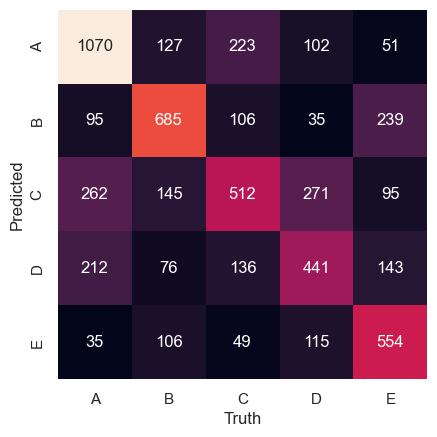

In [27]:
mat = confusion_matrix(pred, y_test)
names = np.unique(pred)
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=names, yticklabels=names)
plt.xlabel('Truth')
plt.ylabel('Predicted')
plt.plot()